# Percobaan Pengaruh Ukuran Filter per Layer Konvolusi

#### Import Dataset

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

Seeding

In [7]:
import random
import os

# Atur seed
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

#### Load Dataset

In [8]:
# Load dataset CIFAR-10
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Split train -> 40k train, 10k validation
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

# Normalisasi data (0-1)
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Train shape: {x_train.shape}, Validation shape: {x_val.shape}, Test shape: {x_test.shape}")

Train shape: (40000, 32, 32, 3), Validation shape: (10000, 32, 32, 3), Test shape: (10000, 32, 32, 3)


## Model 1: Ukuran (3, 3) per Layer

c:\Users\agilf\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.3679 - loss: 1.7406 - val_accuracy: 0.5709 - val_loss: 1.2304
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.5736 - loss: 1.2183 - val_accuracy: 0.6312 - val_loss: 1.0721
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6329 - loss: 1.0515 - val_accuracy: 0.6552 - val_loss: 1.0122
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.6694 - loss: 0.9479 - val_accuracy: 0.6665 - val_loss: 0.9871
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.6985 - loss: 0.8655 - val_accuracy: 0.6747 - val_loss: 0.9691
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7259 - loss: 0.7893 - val_accuracy: 0.6759 - val_loss: 0.9815
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7523 - loss: 0.7223 - val_accuracy: 0.6759 - val_loss: 0.9873
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.7717 - loss: 0.6671 - va

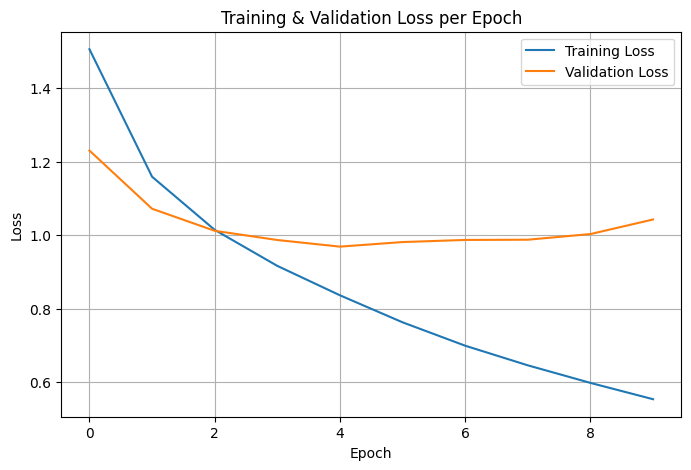

In [9]:
# Make model with [32, 64] Filter
model1 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model1
model1.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Callback
early_stop = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# Training model1
history = model1.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

# Prediksi di test set
y_pred_probs = model1.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Hitung macro F1-Score
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1-Score di Test Set: {f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model 1: Ukuran (5, 5) per Layer

c:\Users\agilf\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - accuracy: 0.3446 - loss: 1.7865 - val_accuracy: 0.5415 - val_loss: 1.2920
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.5518 - loss: 1.2649 - val_accuracy: 0.6063 - val_loss: 1.1355
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.6129 - loss: 1.1125 - val_accuracy: 0.6265 - val_loss: 1.0852
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.6522 - loss: 1.0023 - val_accuracy: 0.6429 - val_loss: 1.0488
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.6797 - loss: 0.9237 - val_accuracy: 0.6468 - val_loss: 1.0388
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.7025 - loss: 0.8590 - val_accuracy: 0.6435 - val_loss: 1.0630
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.7217 - loss: 0.8014 - val_accuracy: 0.6450 - val_loss: 1.0678
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.7462 - loss: 0.7392 - 

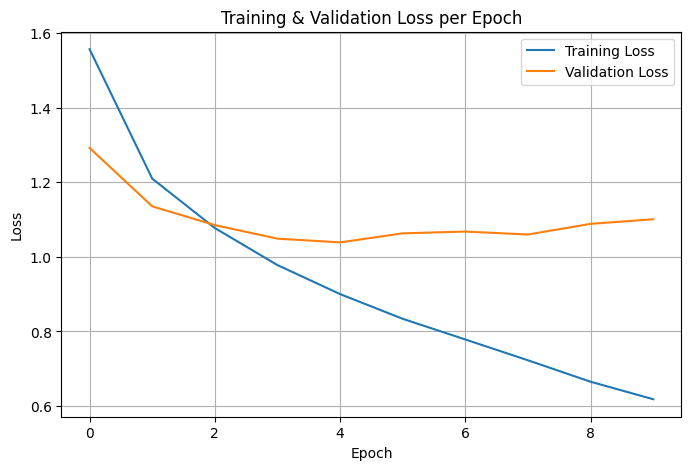

In [10]:
# Make model with 2 convolutional layer
model2 = models.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model2
model2.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Callback
early_stop = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# Training model2
history = model2.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

# Prediksi di test set
y_pred_probs = model2.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Hitung macro F1-Score
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1-Score di Test Set: {f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model 1: Ukuran (7, 7) per Layer

c:\Users\agilf\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.2936 - loss: 1.8994 - val_accuracy: 0.4770 - val_loss: 1.4429
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.4850 - loss: 1.4310 - val_accuracy: 0.5345 - val_loss: 1.3047
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5445 - loss: 1.2836 - val_accuracy: 0.5666 - val_loss: 1.2290
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.5821 - loss: 1.1820 - val_accuracy: 0.5889 - val_loss: 1.1798
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.6095 - loss: 1.1045 - val_accuracy: 0.6044 - val_loss: 1.1428
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.6295 - loss: 1.0499 - val_accuracy: 0.6080 - val_loss: 1.1345
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.6447 - loss: 1.0015 - val_accuracy: 0.6023 - val_loss: 1.1454
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.6643 - loss: 0.9556 - 

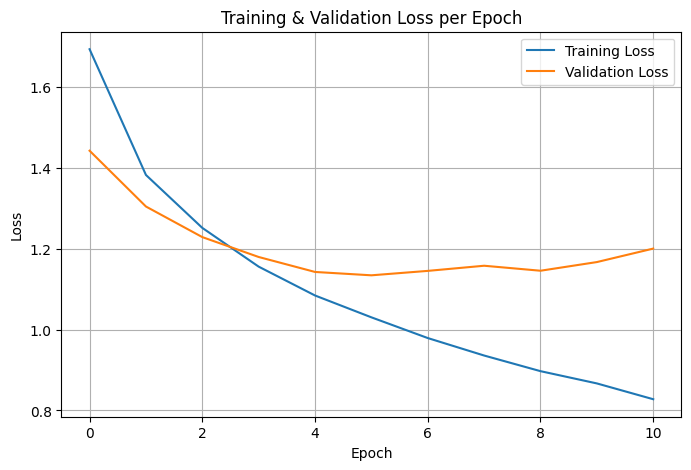

In [11]:
# Make model with [32, 64] Filter
model3 = models.Sequential([
    layers.Conv2D(32, (7, 7), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (7, 7), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model3
model3.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Callback
early_stop = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# Training model3
history = model3.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

# Prediksi di test set
y_pred_probs = model3.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Hitung macro F1-Score
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1-Score di Test Set: {f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()